Original dataset head (first 5 rows):
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------

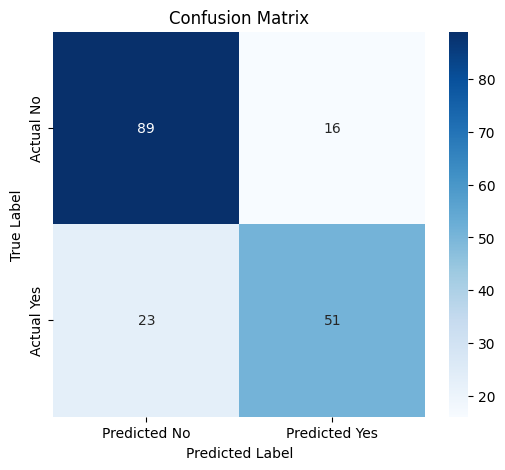

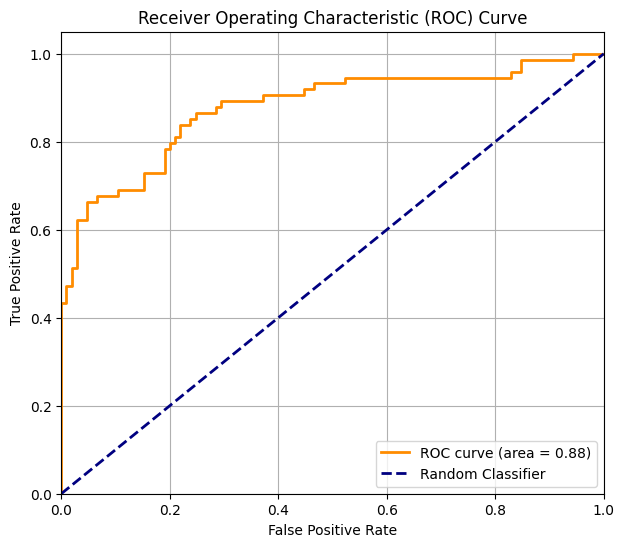


Task Completed!


In [ ]:
# --- Step 1: Import necessary libraries ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 2: Load the Titanic dataset ---
try:
    df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
    df = sns.load_dataset('titanic')
except Exception as e:
    print(f"Could not load Titanic dataset from seaborn. Trying a direct URL. Error: {e}")
    # Fallback to a common public URL if seaborn load fails
    titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(titanic_url)

print("Original dataset head (first 5 rows):")
print(df.head())
print("\nDataset information:")
df.info()

# --- Print actual columns to debug KeyError (left for debugging, can be removed in final code) ---
print("\nActual columns in the DataFrame:")
print(df.columns.tolist())

# --- Step 3: Prepare the Data (Feature Engineering and Preprocessing) ---
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

# Verify if the target column exists first (still good practice to keep these checks)
if target not in df.columns:
    print(f"Error: Target column '{target}' not found in the DataFrame. Available columns are: {df.columns.tolist()}")
    if 'Survived' in df.columns:
        target = 'Survived'
        print(f"Using 'Survived' as the target column instead.")
    else:
        raise KeyError(f"Neither '{target}' nor 'Survived' found in the dataset. Please check your dataset columns.")

# Verify if all feature columns exist
missing_features = [f for f in features if f not in df.columns]
if missing_features:
    print(f"Error: The following feature columns are missing from the DataFrame: {missing_features}")
    print(f"Available columns are: {df.columns.tolist()}")
    if target == 'Survived' and 'Pclass' in df.columns and 'Sex' in df.columns and 'Age' in df.columns and 'SibSp' in df.columns and 'Parch' in df.columns and 'Fare' in df.columns and 'Embarked' in df.columns:
        print("Attempting to use capitalized feature names found in the dataset.")
        features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
        missing_features = [f for f in features if f not in df.columns]
        if missing_features:
             raise KeyError(f"Even with capitalized names, the following feature columns are missing: {missing_features}")
    else:
        raise KeyError("Could not find all required features. Please check your dataset's column names.")


data = df[features + [target]].copy()

# Handle missing values:
# --- CHANGE HERE: Removed inplace=True and reassigned the column ---
data['age'] = data['age'].fillna(data['age'].median())

# --- CHANGE HERE: Removed inplace=True and reassigned the column ---
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

# Handle categorical features:
data = pd.get_dummies(data, columns=['sex', 'embarked'], drop_first=True)

print("\nProcessed data head (first 5 rows after cleaning and encoding):")
print(data.head())
print("\nProcessed dataset information (check for NaNs and data types):")
data.info()

# --- Step 4: Split Data into Training and Testing Sets ---
X = data.drop(target, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# --- Step 5: Implement Logistic Regression Model ---
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

print("\nTraining the Logistic Regression model...")
model.fit(X_train, y_train)
print("Model training complete.")

# --- Step 6: Make Predictions on the Test Set ---
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# --- Step 7: Calculate Performance Metrics ---
print("\n--- Model Performance Metrics ---")

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

# --- Step 8: Plot Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Step 9: Plot ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("\nTask Completed!")